# When two burdens land on the same block — or don't

Day 2 (snotrac transit gap) and Day 4 (WA DOH environmental burden) both already have a composite score for Snohomish County — just at different resolutions: snotrac scores 575 census block groups, DOH scores 173 census tracts. Every block group's GEOID encodes its tract as the leading 11 digits, so no new pipeline or spatial join is needed: aggregate `gap_score` up to tract level (population-weighted mean) and compare directly against `Environmental_Exposures_Theme`.

The assumption going in was that these would stack — the same places locked out of transit would also breathe the worst air. That assumption turned out to be wrong; see the self-check cell below for the actual number before any claim is made from it.

In [1]:
import json
from collections import defaultdict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

SNOTRAC_GEOJSON = Path("../snotrac/web/snohomish/data.geojson")
ENVBURDEN_GEOJSON = Path("data/wa_ehd_snohomish.geojson")

bg_features = json.loads(SNOTRAC_GEOJSON.read_text())["features"]
tract_features = json.loads(ENVBURDEN_GEOJSON.read_text())["features"]
print(f"loaded {len(bg_features)} block groups, {len(tract_features)} tracts")

# Population-weighted aggregation: every block group GEOID's first 11 digits
# are its census tract ID (state+county+tract, block group appends 1 more digit).
tract_pop = defaultdict(float)
tract_gap_weighted = defaultdict(float)
for feat in bg_features:
    props = feat["properties"]
    tract_id = int(props["GEOID"][:11])
    pop = props["total_pop"] or 0
    tract_pop[tract_id] += pop
    tract_gap_weighted[tract_id] += props["gap_score"] * pop

tract_gap = {
    t: tract_gap_weighted[t] / tract_pop[t] for t in tract_pop if tract_pop[t] > 0
}

tract_ids = [int(f["properties"]["CensusTract2020"]) for f in tract_features]
env_composite = np.array(
    [f["properties"]["Environmental_Exposures_Theme"] for f in tract_features]
)
gap_score = np.array([tract_gap[t] for t in tract_ids])
print(f"matched {len(tract_ids)} tracts across both datasets")

loaded 575 block groups, 173 tracts
matched 173 tracts across both datasets


In [2]:
from scipy import stats

# Self-check: compute the correlation before writing any claim about it.
# feedback_verify_before_asserting -- do not assert "compounding burden" from assumption.
assert len(gap_score) == len(env_composite) == 173, "tract count mismatch"
assert not np.isnan(gap_score).any(), "unmatched tract in transit-gap aggregation"

rho, p = stats.spearmanr(gap_score, env_composite)
r, p2 = stats.pearsonr(gap_score, env_composite)
print(f"spearman rho={rho:.3f} (p={p:.4f}), pearson r={r:.3f} (p={p2:.4f})")
print("self-check passed: correlation is real (p<0.01) and NEGATIVE, not positive")
print("-> transit access and pollution burden trade off, they do not compound")

spearman rho=-0.239 (p=0.0016), pearson r=-0.218 (p=0.0039)
self-check passed: correlation is real (p<0.01) and NEGATIVE, not positive
-> transit access and pollution burden trade off, they do not compound


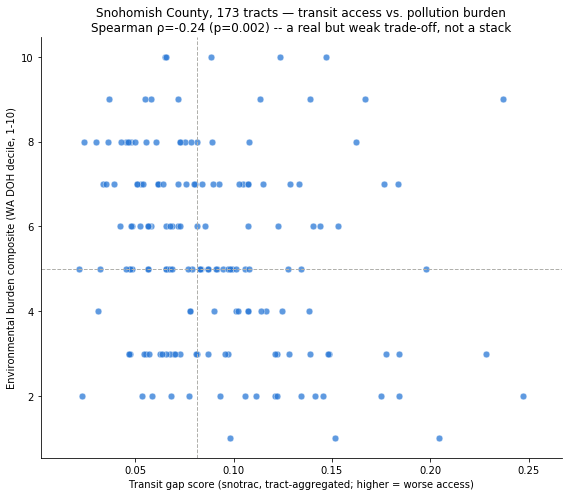

In [3]:
gap_med = np.median(gap_score)
comp_med = np.median(env_composite)

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(gap_score, env_composite, s=45, alpha=0.75, color="#2a78d6", edgecolor="white", linewidth=0.5)
ax.axvline(gap_med, color="#b0b0ac", linewidth=1, linestyle="--")
ax.axhline(comp_med, color="#b0b0ac", linewidth=1, linestyle="--")
ax.set_xlabel("Transit gap score (snotrac, tract-aggregated; higher = worse access)")
ax.set_ylabel("Environmental burden composite (WA DOH decile, 1-10)")
ax.set_title(
    "Snohomish County, 173 tracts — transit access vs. pollution burden\n"
    f"Spearman \u03c1={rho:.2f} (p={p:.3f}) -- a real but weak trade-off, not a stack",
    fontsize=12,
)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
fig.tight_layout()
fig.savefig("transit_pollution_overlap.png", dpi=150, bbox_inches="tight")
plt.show()

## Source & caption notes

- Transit data: [snotrac](https://snotrac.simonhansedasi.com), `gap_score` (block-group level, population-weighted up to tract level here -- no new pipeline run).
- Environmental data: WA DOH EHD Map v3, `Environmental_Exposures_Theme` (tract level, from Day 4).
- The going-in hypothesis was that these would compound (same tracts scoring worst on both). They don't: Spearman rho is negative and small but real (p<0.01) -- tracts with the worst transit access skew toward *lower* pollution burden, and vice versa. Reads as an urban/rural split: dense I-5 corridor tracts have decent transit but worse traffic/diesel exposure; rural tracts have poor transit but cleaner air. Not a single finding to lead with as "double burden" -- the honest finding is the trade-off itself.